In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
!pip install imblearn

!pip install xgboost

In [2]:
df = pd.read_csv("ola_driver_scaler.csv")

In [3]:
df.shape
df.head(10)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
5,5,12/01/19,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
6,6,01/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
7,7,02/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
8,8,03/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,350000,1
9,9,04/01/20,4,43.0,0.0,C13,2,65603,12/07/19,27/04/20,2,2,0,1


In [4]:

df.info()
df.isna().sum()/df.count()*100
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [5]:
df.head()
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [7]:
#most drivers are between the age of 21 and 58
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [8]:
#converting column containg date from string to date type
#extracting the number from city code given in string
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])

"""
df['City']=df['City'].str[1:].astype(int)
df['Reporting_month']=df['MMM-YY'].dt.month
df['Reporting_year']=df['MMM-YY'].dt.year
df['DOJ_month']=df['Dateofjoining'].dt.month
df['DOJ_year']=df['Dateofjoining'].dt.year

churn=[]
for i in df.LastWorkingDate:
    if i == pd.NaT:
        churn.append(0)
    else:
        churn.append(1)

df['churn']=churn

for i in df['churn']:
    if i!=0:
        df['LWD_month']=df['LastWorkingDate'].dt.month
        df['LWD_year']=df['LastWorkingDate'].dt.year
      
        
df=df.drop(columns=['MMM-YY','Dateofjoining','LastWorkingDate'])  




"""

"\ndf['City']=df['City'].str[1:].astype(int)\ndf['Reporting_month']=df['MMM-YY'].dt.month\ndf['Reporting_year']=df['MMM-YY'].dt.year\ndf['DOJ_month']=df['Dateofjoining'].dt.month\ndf['DOJ_year']=df['Dateofjoining'].dt.year\n\nchurn=[]\nfor i in df.LastWorkingDate:\n    if i == pd.NaT:\n        churn.append(0)\n    else:\n        churn.append(1)\n\ndf['churn']=churn\n\nfor i in df['churn']:\n    if i!=0:\n        df['LWD_month']=df['LastWorkingDate'].dt.month\n        df['LWD_year']=df['LastWorkingDate'].dt.year\n      \n        \ndf=df.drop(columns=['MMM-YY','Dateofjoining','LastWorkingDate'])  \n\n\n\n\n"

In [9]:
df.duplicated().sum()



0

In [10]:
df.sample(5)
#print(type(df.Driver_ID.unique()))
      
#df[df["Driver_ID"]==2768]

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
6821,2020-12-01,1029,24.0,0.0,C17,0,20363,2020-12-18,NaT,1,1,0,1
10034,2020-04-01,1490,38.0,1.0,C21,0,71142,2020-03-20,NaT,2,2,0,1
12031,2019-07-01,1789,31.0,0.0,C25,1,22875,2019-07-04,NaT,1,1,0,1
1548,2019-09-01,229,43.0,0.0,C28,0,104995,2019-08-03,NaT,4,4,600000,1
1414,2020-08-01,210,38.0,0.0,C29,2,64583,2020-05-03,NaT,3,3,0,1


In [11]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: datetime64[ns

In [12]:
df.columns

Index(['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')

### KNN Imputation

In [13]:
###KNN IMPUTATION
df_num=df.select_dtypes(np.number)     #Gives a dataframe
df_num.drop(columns='Driver_ID',inplace=True)
df_num.head()
col=[]
col=df_num.columns


C:\Users\Shreha\anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [14]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean',)
imputer.fit(df_num)# transform the dataset_data_new = imputer.transform(_data_nums)
df_num_new=imputer.transform(df_num)   #gives ndarray
df_num_new

#converting ndarray to dataframe
df_num_new_df = pd.DataFrame(df_num_new, columns = col)   

#creating another dataframe for the remaining columns
df_1=pd.DataFrame()
df_1=df
df_1=df_1.drop(columns=col,axis=1)

#concatenating two dataframes
df_1=pd.concat([df_1,df_num_new_df],axis=1)
df_1

,MMM-YY,Driver_ID,City,Dateofjoining,LastWorkingDate,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,2019-01-01,1,C23,2018-12-24,NaT,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0
1,2019-02-01,1,C23,2018-12-24,NaT,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0
2,2019-03-01,1,C23,2018-12-24,2019-03-11,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0
3,2020-11-01,2,C7,2020-11-06,NaT,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
4,2020-12-01,2,C7,2020-11-06,NaT,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,2020-08-01,2788,C27,2020-06-08,NaT,30.0,0.0,2.0,70254.0,2.0,2.0,740280.0,3.0
19100,2020-09-01,2788,C27,2020-06-08,NaT,30.0,0.0,2.0,70254.0,2.0,2.0,448370.0,3.0
19101,2020-10-01,2788,C27,2020-06-08,NaT,30.0,0.0,2.0,70254.0,2.0,2.0,0.0,2.0
19102,2020-11-01,2788,C27,2020-06-08,NaT,30.0,0.0,2.0,70254.0,2.0,2.0,200420.0,2.0


In [15]:
df.shape

(19104, 13)

In [16]:
df_1.shape

(19104, 13)

In [17]:
df_1.isna().sum()/df.count()*100

Age                        0.000000
City                       0.000000
Dateofjoining              0.000000
Driver_ID                  0.000000
Education_Level            0.000000
Gender                     0.000000
Grade                      0.000000
Income                     0.000000
Joining Designation        0.000000
LastWorkingDate         1082.178218
MMM-YY                     0.000000
Quarterly Rating           0.000000
Total Business Value       0.000000
dtype: float64

### Grouping by Driver_Id and month

In [18]:
func_dict = {'Age':'max', 'Gender':'first','City':'first', 'Education_Level':'last',
             'Income':'last', 'Joining Designation':'last','Grade':'last', 'Dateofjoining':'last',
             'LastWorkingDate':'last', 'Total Business Value':'sum','Quarterly Rating':'last'} 

df_1_groupby=df_1.groupby(['Driver_ID','MMM-YY']).aggregate(func_dict)

In [19]:

df_1_groupby.sort_index(ascending=[True,True])
df_1_groupby=df_1_groupby.drop(columns=['Total Business Value'],axis=1)
df_1_groupby.head()
df_final=df_1_groupby.groupby(['Driver_ID']).tail(1)

In [20]:
df_final.shape

(2381, 10)

### Groupby at Driver_ID level

In [21]:
func_dict = {'Age':'max', 'Gender':'first','City':'first', 'Education_Level':'last',
             'Income':'last', 'Joining Designation':'last','Grade':'last', 'Dateofjoining':'last',
             'LastWorkingDate':'last', 'Total Business Value':'sum','Quarterly Rating':'last'} 

df_1_groupby_2=df_1.groupby(['Driver_ID',]).aggregate(func_dict)

In [22]:

df_1_groupby_2.shape

(2381, 11)

In [23]:
total_b=[]
total_b=df_1_groupby_2['Total Business Value'].tolist()
len(total_b)

2381

In [24]:
df_final['Total Business Value']=total_b

C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/3813512196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Total Business Value']=total_b


In [25]:
df_final.head()

,,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Quarterly Rating,Total Business Value
Driver_ID,MMM-YY,,,,,,,,,,,
1,2019-03-01,28.0,0.0,C23,2.0,57387.0,1.0,1.0,2018-12-24,2019-03-11,2.0,1715580.0
2,2020-12-01,31.0,0.0,C7,2.0,67016.0,2.0,2.0,2020-11-06,NaT,1.0,0.0
4,2020-04-01,43.0,0.0,C13,2.0,65603.0,2.0,2.0,2019-12-07,2020-04-27,1.0,350000.0
5,2019-03-01,29.0,0.0,C9,0.0,46368.0,1.0,1.0,2019-01-09,2019-03-07,1.0,120360.0
6,2020-12-01,31.0,1.0,C11,1.0,78728.0,3.0,3.0,2020-07-31,NaT,2.0,1265000.0


### Creating a new feature based on increase in quarter rating

In [26]:
#Quarterly rating at the beginning
df_f = df_1_groupby.groupby(['Driver_ID']).first()


#Quarterly rating at the end
df_l = df_1_groupby.groupby(['Driver_ID']).tail(1)


df_comp=pd.DataFrame()

qtr_f_list=df_f['Quarterly Rating'].tolist()
qtr_l_list=df_l['Quarterly Rating'].tolist()
df_comp['Quarterly Rating_first']=qtr_f_list
df_comp['Quarterly Rating_last']=qtr_l_list

df_comp['Quarter_Rating_Increase'] = np.where((df_comp['Quarterly Rating_first'] < df_comp['Quarterly Rating_last']), '1','0')
df_comp.head()

qtr_Rating_Increase_List=df_comp['Quarter_Rating_Increase'].tolist()
df_final['Quarter_Rating_Increase']=qtr_Rating_Increase_List
df_final['Quarter_Rating_Increase']=df_final['Quarter_Rating_Increase'].astype('int')

df_final.head()


C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/1572350326.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Quarter_Rating_Increase']=qtr_Rating_Increase_List
C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/1572350326.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Quarter_Rating_Increase']=df_final['Quarter_Rating_Increase'].astype('int')


,,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Quarterly Rating,Total Business Value,Quarter_Rating_Increase
Driver_ID,MMM-YY,,,,,,,,,,,,
1,2019-03-01,28.0,0.0,C23,2.0,57387.0,1.0,1.0,2018-12-24,2019-03-11,2.0,1715580.0,0
2,2020-12-01,31.0,0.0,C7,2.0,67016.0,2.0,2.0,2020-11-06,NaT,1.0,0.0,0
4,2020-04-01,43.0,0.0,C13,2.0,65603.0,2.0,2.0,2019-12-07,2020-04-27,1.0,350000.0,0
5,2019-03-01,29.0,0.0,C9,0.0,46368.0,1.0,1.0,2019-01-09,2019-03-07,1.0,120360.0,0
6,2020-12-01,31.0,1.0,C11,1.0,78728.0,3.0,3.0,2020-07-31,NaT,2.0,1265000.0,1


### Creating a new feature based on increase in monthly Income

In [27]:


incm_f_list=df_f['Income'].tolist()
incm_l_list=df_l['Income'].tolist()
df_comp['Income_first']=qtr_f_list
df_comp['Income_last']=qtr_l_list

df_comp['Income_Increase'] = np.where((df_comp['Income_first'] < df_comp['Income_last']), '1','0')
df_comp.head()

Income_Increase_List=df_comp['Income_Increase'].tolist()
df_final['Income_Increase']=Income_Increase_List
df_final['Income_Increase']=df_final['Income_Increase'].astype('int')
df_final.head()


C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/3799626428.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Income_Increase']=Income_Increase_List
C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/3799626428.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Income_Increase']=df_final['Income_Increase'].astype('int')


,,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Quarterly Rating,Total Business Value,Quarter_Rating_Increase,Income_Increase
Driver_ID,MMM-YY,,,,,,,,,,,,,
1,2019-03-01,28.0,0.0,C23,2.0,57387.0,1.0,1.0,2018-12-24,2019-03-11,2.0,1715580.0,0,0
2,2020-12-01,31.0,0.0,C7,2.0,67016.0,2.0,2.0,2020-11-06,NaT,1.0,0.0,0,0
4,2020-04-01,43.0,0.0,C13,2.0,65603.0,2.0,2.0,2019-12-07,2020-04-27,1.0,350000.0,0,0
5,2019-03-01,29.0,0.0,C9,0.0,46368.0,1.0,1.0,2019-01-09,2019-03-07,1.0,120360.0,0,0
6,2020-12-01,31.0,1.0,C11,1.0,78728.0,3.0,3.0,2020-07-31,NaT,2.0,1265000.0,1,1


### Create a target variable i.e Churn out variable

In [28]:
lst=[]
lwd_l_list=df_l['LastWorkingDate'].tolist()
churn=[]
for i in lwd_l_list :
    if pd.isnull(i):
        churn.append('0')
    else:
        churn.append('1')
df_final['Churn']=churn
df_final['Churn']


C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/1110502462.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Churn']=churn


Driver_ID  MMM-YY    
1          2019-03-01    1
2          2020-12-01    0
4          2020-04-01    1
5          2019-03-01    1
6          2020-12-01    0
                        ..
2784       2020-12-01    0
2785       2020-10-01    1
2786       2019-09-01    1
2787       2019-06-01    1
2788       2020-12-01    0
Name: Churn, Length: 2381, dtype: object

In [29]:
df_final.head()


,,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Dateofjoining,LastWorkingDate,Quarterly Rating,Total Business Value,Quarter_Rating_Increase,Income_Increase,Churn
Driver_ID,MMM-YY,,,,,,,,,,,,,,
1,2019-03-01,28.0,0.0,C23,2.0,57387.0,1.0,1.0,2018-12-24,2019-03-11,2.0,1715580.0,0,0,1
2,2020-12-01,31.0,0.0,C7,2.0,67016.0,2.0,2.0,2020-11-06,NaT,1.0,0.0,0,0,0
4,2020-04-01,43.0,0.0,C13,2.0,65603.0,2.0,2.0,2019-12-07,2020-04-27,1.0,350000.0,0,0,1
5,2019-03-01,29.0,0.0,C9,0.0,46368.0,1.0,1.0,2019-01-09,2019-03-07,1.0,120360.0,0,0,1
6,2020-12-01,31.0,1.0,C11,1.0,78728.0,3.0,3.0,2020-07-31,NaT,2.0,1265000.0,1,1,0


In [30]:
df_final.drop(columns=['Dateofjoining','LastWorkingDate'],axis=1,inplace=True)
df_final.head()

C:\Users\Shreha\anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Quarterly Rating,Total Business Value,Quarter_Rating_Increase,Income_Increase,Churn
Driver_ID,MMM-YY,,,,,,,,,,,,
1,2019-03-01,28.0,0.0,C23,2.0,57387.0,1.0,1.0,2.0,1715580.0,0,0,1
2,2020-12-01,31.0,0.0,C7,2.0,67016.0,2.0,2.0,1.0,0.0,0,0,0
4,2020-04-01,43.0,0.0,C13,2.0,65603.0,2.0,2.0,1.0,350000.0,0,0,1
5,2019-03-01,29.0,0.0,C9,0.0,46368.0,1.0,1.0,1.0,120360.0,0,0,1
6,2020-12-01,31.0,1.0,C11,1.0,78728.0,3.0,3.0,2.0,1265000.0,1,1,0


In [31]:
df_final.columns
df_final.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2381 entries, (1, Timestamp('2019-03-01 00:00:00')) to (2788, Timestamp('2020-12-01 00:00:00'))
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      2381 non-null   float64
 1   Gender                   2381 non-null   float64
 2   City                     2381 non-null   object 
 3   Education_Level          2381 non-null   float64
 4   Income                   2381 non-null   float64
 5   Joining Designation      2381 non-null   float64
 6   Grade                    2381 non-null   float64
 7   Quarterly Rating         2381 non-null   float64
 8   Total Business Value     2381 non-null   float64
 9   Quarter_Rating_Increase  2381 non-null   int32  
 10  Income_Increase          2381 non-null   int32  
 11  Churn                    2381 non-null   object 
dtypes: float64(8), int32(2), object(2)
memory usage: 295.0+ KB


### Univariant Analysis of feature

In [32]:
num_col=[]
num_col_cat=[]
for i in df_final.columns:
    if len(df_final[i].unique()) < 13:
        num_col_cat.append(i);
    else:
        num_col.append(i)

In [33]:
num_col

['Age', 'City', 'Income', 'Total Business Value']

In [34]:
num_col_cat

['Gender',
 'Education_Level',
 'Joining Designation',
 'Grade',
 'Quarterly Rating',
 'Quarter_Rating_Increase',
 'Income_Increase',
 'Churn']

C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Shreha\anaconda3\li

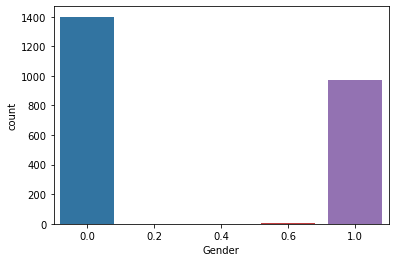

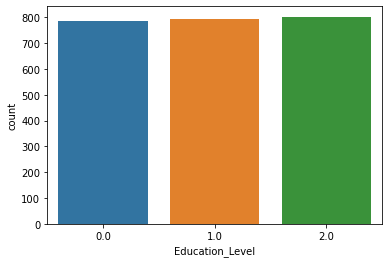

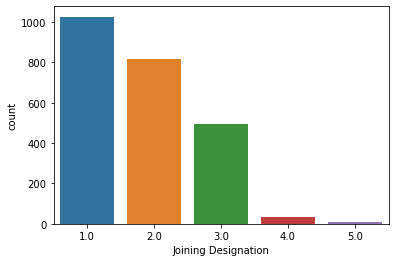

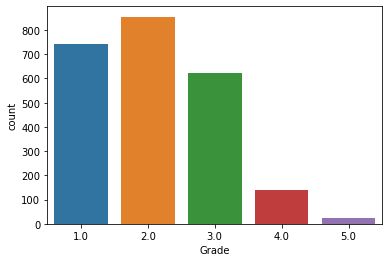

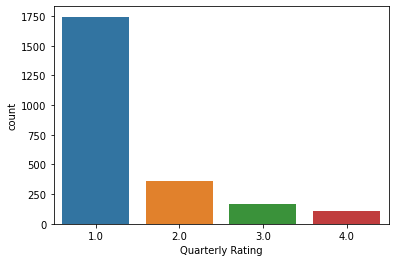

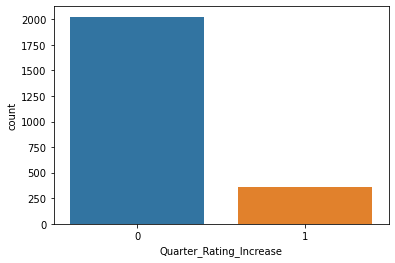

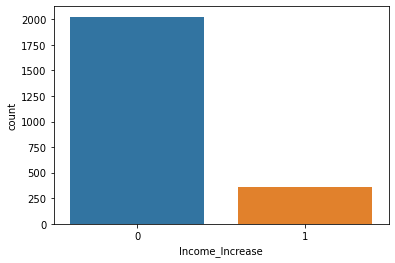

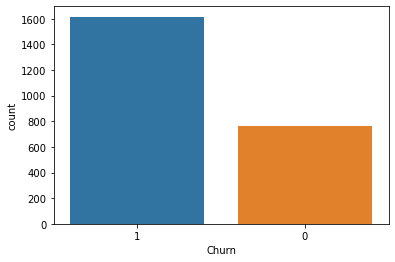

In [35]:
#Analysis of single categorial feature
for i in num_col_cat:
    fig,axes = plt.subplots(1,1,figsize=(6,4))
    sns.countplot(df_final[i])
    


C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Age', ylabel='count'>

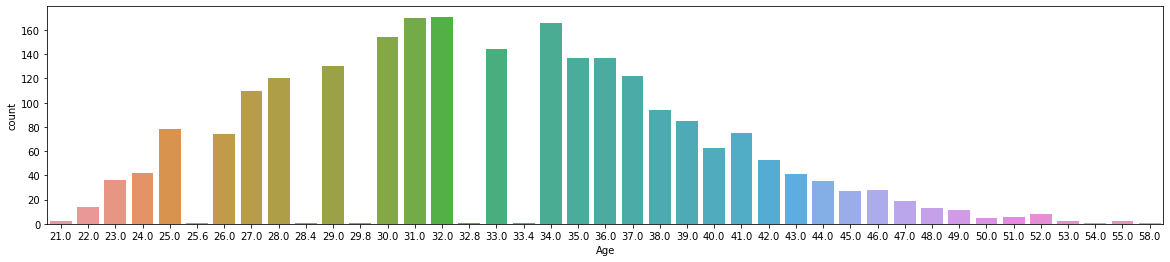

In [36]:
fig,axes = plt.subplots(1,1,figsize=(20,4))
sns.countplot(df_final['Age'])

C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).


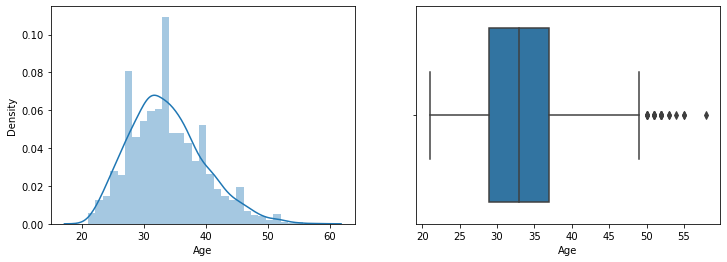

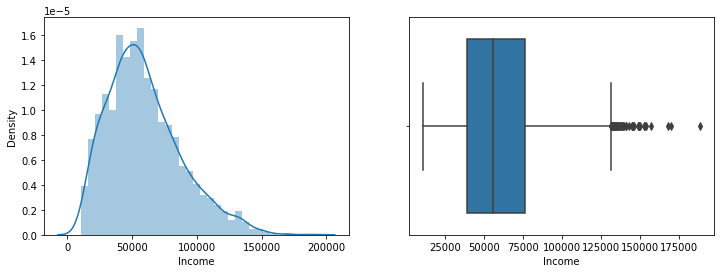

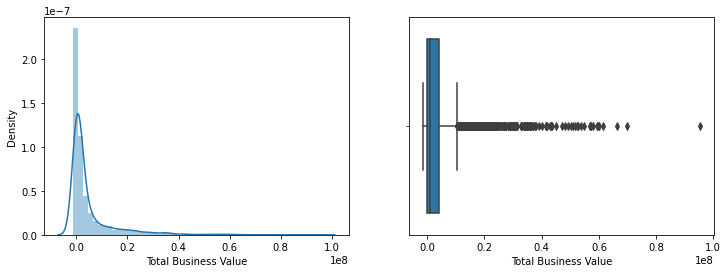

In [37]:
#Analysis of single continuous feature
for i in num_col:
    if i != 'City':
        fig,axes =plt.subplots(1,2,figsize=(12,4))
        sns.distplot(df_final[i],ax=axes[0])
        sns.boxplot(df_final[i], ax=axes[1])

In [38]:
for i in num_col:
    if i != 'City':
        print(i+"  :  "+str(df[i].skew()))

Age  :  0.43614751796055357
Income  :  0.7059850785712668
Total Business Value  :  6.970166341268835


### Bivariant Analysis

In [39]:
print(df_final['Churn'].value_counts())


1    1616
0     765
Name: Churn, dtype: int64


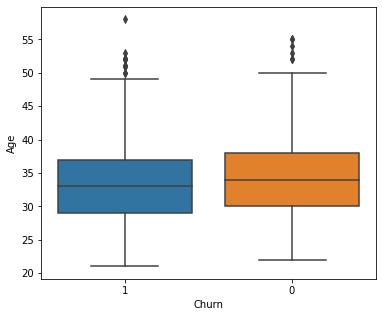

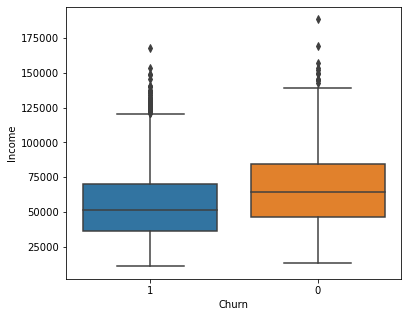

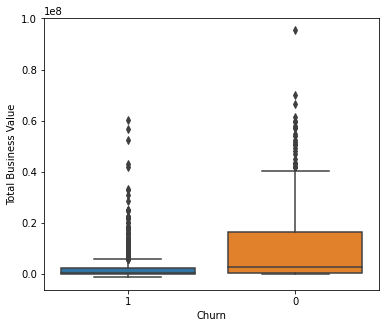

In [40]:
for i in num_col:
    if i != 'City':
        fig,axes = plt.subplots(1,1,figsize=(6,5))
        sns.boxplot(x=df_final['Churn'], y=df_final[i])

<AxesSubplot:xlabel='City', ylabel='count'>

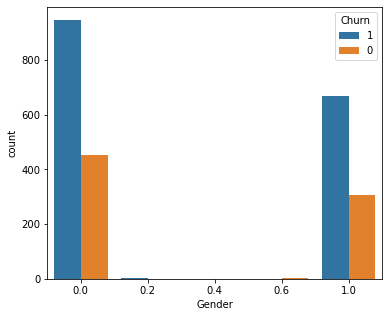

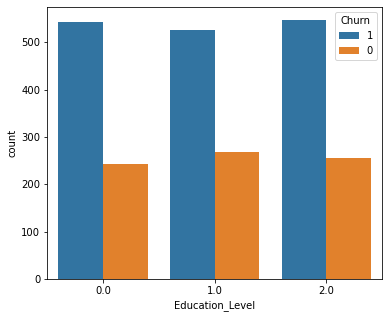

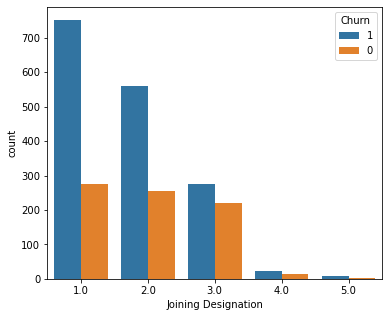

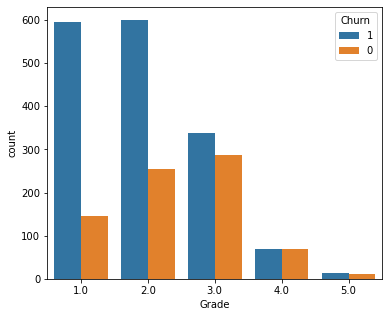

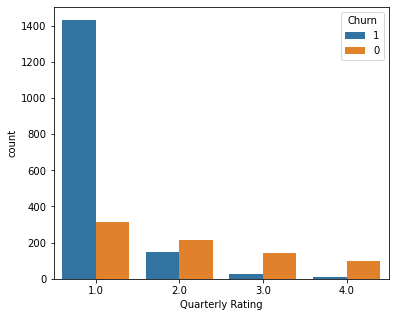

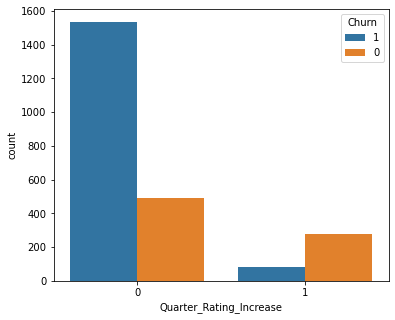

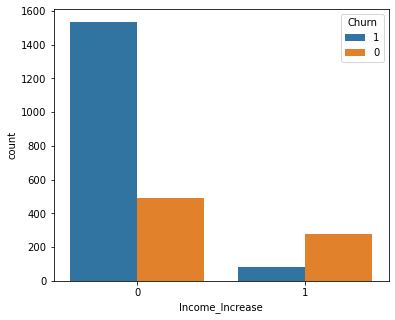

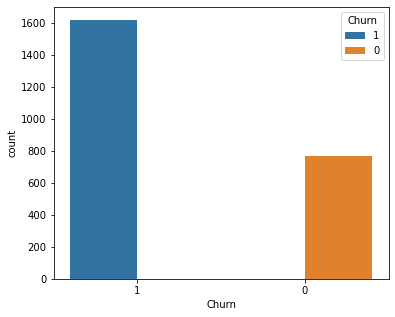

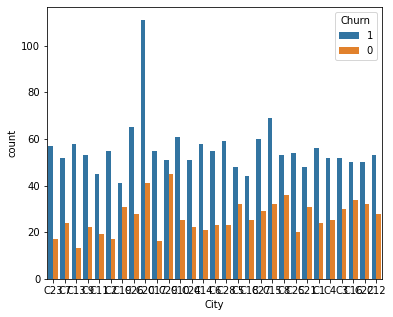

In [41]:
for i in num_col_cat:
        fig,axes = plt.subplots(1,1,figsize=(6,5))
        sns.countplot(x=df_final[i], hue=df_final['Churn'])
fig,axes = plt.subplots(1,1,figsize=(6,5))
sns.countplot(x=df_final['City'], hue=df_final['Churn'])


In [42]:
df_final.duplicated().sum()

0

### Outliers removal

In [43]:

Q1 = df[num_col]. quantile(0.25)
Q3 = df[num_col]. quantile(0.75)
IQR = Q3 - Q1
df_final = df_final[~((df_final[num_col] < (Q1 - 1.5 * IQR)) |(df_final[num_col] > (Q3 + 1.5 * IQR))). any(axis=1)]

C:\Users\Shreha\AppData\Local\Temp/ipykernel_6160/1998162565.py:4: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version.  Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  df_final = df_final[~((df_final[num_col] < (Q1 - 1.5 * IQR)) |(df_final[num_col] > (Q3 + 1.5 * IQR))). any(axis=1)]


C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


-645150.0
1742410.0


C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Shreha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.wa

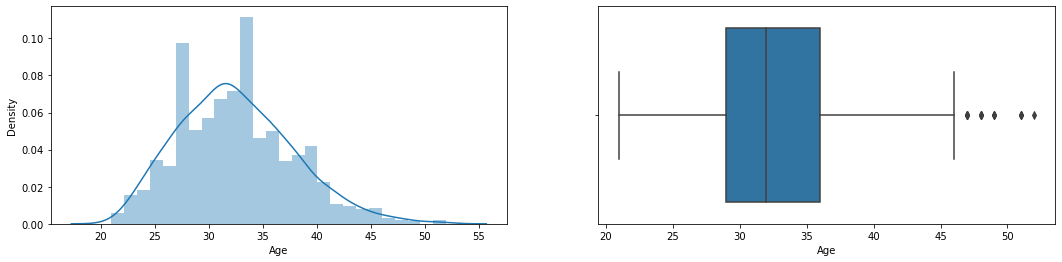

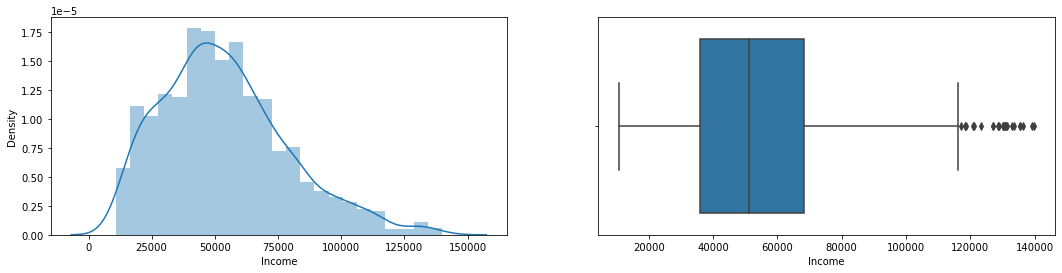

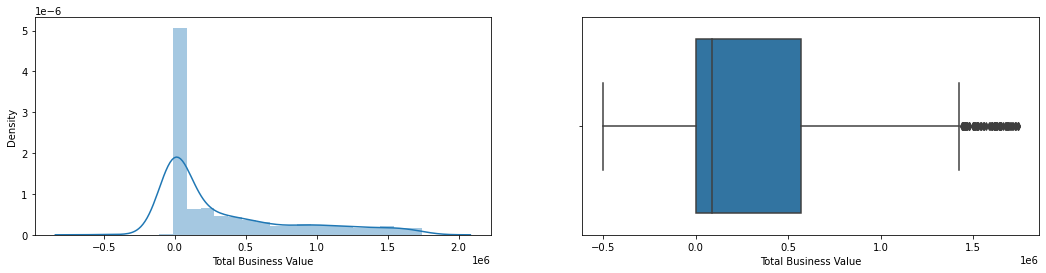

In [44]:
q1=df_final['Total Business Value'] .quantile(0.0)
print(q1)
df_final=df_final[df_final['Total Business Value'] > q1 ]

q4=df_final['Total Business Value'] .quantile(1.0)
print(q4)
df_final=df_final[df_final['Total Business Value'] < q4 ]




#Analysis of single continuous feature
for i in num_col:
    if i != 'City':
        fig,axes =plt.subplots(1,2,figsize=(18,4))
        sns.distplot(df_final[i],ax=axes[0])
        sns.boxplot(df_final[i], ax=axes[1])

### One hot encoding of city feature


In [45]:
df_final = pd.get_dummies(df_final, columns=['City'], drop_first=True)

In [46]:
df_final.shape
df_final.drop(columns=['Income','Quarterly Rating'], inplace=True)

### Data Preparation for modelling

In [47]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_final, test_size=0.30, random_state=42)
print(train.shape)
print(test.shape)

(1019, 37)
(438, 37)


In [48]:
x_train, y_train = train.drop('Churn', axis=1), train.Churn
x_test, y_test = test.drop('Churn', axis=1), test.Churn

### Standarize the input X column

In [49]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)


In [50]:
df_final.columns

Index(['Age', 'Gender', 'Education_Level', 'Joining Designation', 'Grade',
       'Total Business Value', 'Quarter_Rating_Increase', 'Income_Increase',
       'Churn', 'City_C10', 'City_C11', 'City_C12', 'City_C13', 'City_C14',
       'City_C15', 'City_C16', 'City_C17', 'City_C18', 'City_C19', 'City_C2',
       'City_C20', 'City_C21', 'City_C22', 'City_C23', 'City_C24', 'City_C25',
       'City_C26', 'City_C27', 'City_C28', 'City_C29', 'City_C3', 'City_C4',
       'City_C5', 'City_C6', 'City_C7', 'City_C8', 'City_C9'],
      dtype='object')

In [51]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1019, 36), (438, 36), (1019,), (438,))

# MODEL

### 1.Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scale,y_train)

y_pred=lr.predict(x_test_scale)


from sklearn.metrics import confusion_matrix
con_mat = confusion_matrix(y_pred,y_test)
print(classification_report(y_test, y_pred))
print(con_mat)

              precision    recall  f1-score   support

           0       0.64      0.21      0.32       100
           1       0.80      0.96      0.88       338

    accuracy                           0.79       438
   macro avg       0.72      0.59      0.60       438
weighted avg       0.77      0.79      0.75       438

[[ 21  12]
 [ 79 326]]


### Random Classifier with class weights

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix

param = {'max_depth':[2,3,4],'n_estimators':[50,100,150,200]}
random_forest = RandomForestClassifier(class_weight ='balanced')
c=GridSearchCV(random_forest,param,cv=3,scoring='f1')
c.fit(x_train,y_train)

def display(results): 
    print(f'Best parameters are : {results.best_params_}') 
    print(f'The score is : {results.best_score_}')
display(c)

y_pred = c.predict(x_test) 

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)


C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

Best parameters are : {'max_depth': 2, 'n_estimators': 50}
The score is : nan
              precision    recall  f1-score   support

           0       0.33      0.64      0.43       100
           1       0.85      0.61      0.71       338

    accuracy                           0.62       438
   macro avg       0.59      0.63      0.57       438
weighted avg       0.73      0.62      0.65       438

[[ 64  36]
 [131 207]]


C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:696: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 199, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 242, in _score
    return self._sign * self._score_func(y_true, y_pred,
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "C:\Users\Shreha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py", line 1071, in f1_score
    return fbeta_sc

### XGBoost Classifier

In [54]:
import xgboost as xgb

my_model = xgb.XGBClassifier(class_weight='balanced')
my_model.fit(x_train, y_train) # Predicting the Test set results
y_pred = my_model.predict(x_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix



[23:23:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "class_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[23:23:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\Users\Shreha\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


              precision    recall  f1-score   support

           0       0.46      0.32      0.38       100
           1       0.82      0.89      0.85       338

    accuracy                           0.76       438
   macro avg       0.64      0.61      0.62       438
weighted avg       0.74      0.76      0.74       438



### Decision Tree Classifier

In [55]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
clf = clf.fit(x_train,y_train) 
y_pred = clf.predict(x_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)


              precision    recall  f1-score   support

           0       0.31      0.33      0.32       100
           1       0.80      0.78      0.79       338

    accuracy                           0.68       438
   macro avg       0.55      0.56      0.55       438
weighted avg       0.69      0.68      0.68       438

[[ 33  67]
 [ 74 264]]


### Random forest classifier is the best model among all tested classification model for churn prediction  